# Research Question
Can we accurately predict the class of the student (classified as High, Medium, or Low academic achievement) based on their participation characteristic? Which participation feature most contributes to these classes?

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random

## Upload the kaggle dataset and print out relevant information to learn more about the data I am dealing with

In [2]:
df = pd.read_csv('Participation_data.csv')
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [3]:
print("Info on dataset:")
df.info()

print("\n\nDescribe the dataset:")
df.describe()

print("\n\nShape:")
print(df.shape)

Info on dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  Parentsch

As stated on the Kaggle dataset page, this is what each variable that we will be using means: 


*   raisedhands- how many times the student raises his/her hand in the classroom(numeric value: 0-100)
*   visITedResources- how many times the student visits the course content(numeric value: 0-100)
*   AnnouncementsView- how many times the student checks the new announcements(numeric value: 0-100)
*   Discussion- how many times the student participate in discussion groups (numeric value: 0-100)
*   ParentAnsweringSurvey- if the parent answered the surveys which are provided from school or not (either 'Yes' or 'No')
*   ParentschoolSatisfaction- if the parent is satisfaction with the school(either 'Yes' or 'No')
*   StudentAbsenceDays- the number of absence days for each student (either 'above-7' or 'under-7')
*   Class- students interval levels based on their grade (Low-Level: 0 to 69,Middle-Level: 70 to 89, High-Level: 90-100.)

All of this information can be found on [this Kaggle page](https://www.kaggle.com/datasets/aljarah/xAPI-Edu-Data)

# Pre-process data (make sure there are no empty/out of place data)
I want to use all of the participation columns in the dataset, so we need to make sure that none of them are empty

In [4]:
def check_for_empty_vals(name_of_column, data_frame):
  data_frame[name_of_column]

  df_empty = data_frame[data_frame[name_of_column].apply(lambda val: pd.isna(val) or (hasattr(val, '__len__') and len(val) == 0))]
  print(df_empty)
  if len(df_empty):
    data_frame = data_frame[~data_frame[name_of_column].apply(lambda val: pd.isna(val) or (hasattr(val, '__len__') and len(val) == 0))]

  return data_frame

In [5]:
columns = df.columns.tolist()
for column in columns:
  df = check_for_empty_vals(column, df)

Empty DataFrame
Columns: [gender, NationalITy, PlaceofBirth, StageID, GradeID, SectionID, Topic, Semester, Relation, raisedhands, VisITedResources, AnnouncementsView, Discussion, ParentAnsweringSurvey, ParentschoolSatisfaction, StudentAbsenceDays, Class]
Index: []
Empty DataFrame
Columns: [gender, NationalITy, PlaceofBirth, StageID, GradeID, SectionID, Topic, Semester, Relation, raisedhands, VisITedResources, AnnouncementsView, Discussion, ParentAnsweringSurvey, ParentschoolSatisfaction, StudentAbsenceDays, Class]
Index: []
Empty DataFrame
Columns: [gender, NationalITy, PlaceofBirth, StageID, GradeID, SectionID, Topic, Semester, Relation, raisedhands, VisITedResources, AnnouncementsView, Discussion, ParentAnsweringSurvey, ParentschoolSatisfaction, StudentAbsenceDays, Class]
Index: []
Empty DataFrame
Columns: [gender, NationalITy, PlaceofBirth, StageID, GradeID, SectionID, Topic, Semester, Relation, raisedhands, VisITedResources, AnnouncementsView, Discussion, ParentAnsweringSurvey, Par

Sanity check: above, I was able to see that there were no empty values in my dataset. Thus, I do not need to deal with this in order to make predictions with my ML model later on.

# Encode the data
Some of the data points I would like to use are strings. However, we need the labels of participation to have numerical values for our machine learning model.

In [6]:
df['ParentschoolSatisfaction'] = df['ParentschoolSatisfaction'].str.strip().str.capitalize()
df['ParentschoolSatisfaction'] = df['ParentschoolSatisfaction'].map({'Good': 1, 'Bad': 0})

df['ParentAnsweringSurvey'] = df['ParentAnsweringSurvey'].str.strip().str.capitalize()
df['ParentAnsweringSurvey'] = df['ParentAnsweringSurvey'].map({'Yes': 1, 'No': 0})

df['StudentAbsenceDays'] = df['StudentAbsenceDays'].str.strip().str.capitalize()
df['StudentAbsenceDays'] = df['StudentAbsenceDays'].map({'Under-7': 0, 'Above-7': 1})

df['Class'] = df['Class'].str.strip().str.capitalize()
df['Class'] = df['Class'].map({'L': 0, 'M': 1, 'H': 2})

In [7]:
def plot_column_distribution(df, column_name):

    colors = ["skyblue", "salmon", "lightgreen", "gold", "plum", "coral", "lightslategray"]
    color = random.choice(colors)
    plt.hist(df[column_name], bins=10, edgecolor='black', color=color)
    plt.xlabel(f"{column_name.capitalize()} Value")
    plt.ylabel("Number of Students")
    plt.title(f"Distribution of {column_name.capitalize()}")
    plt.show()


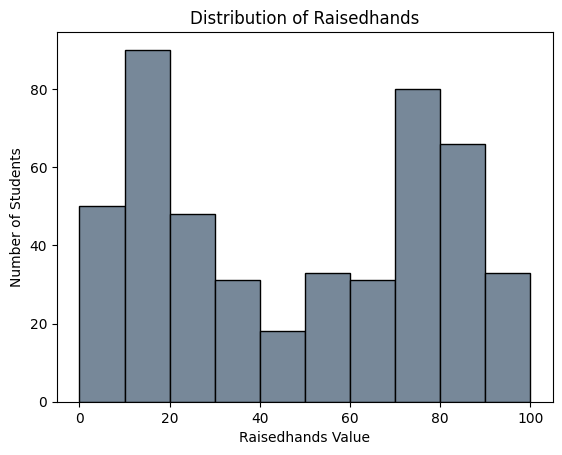

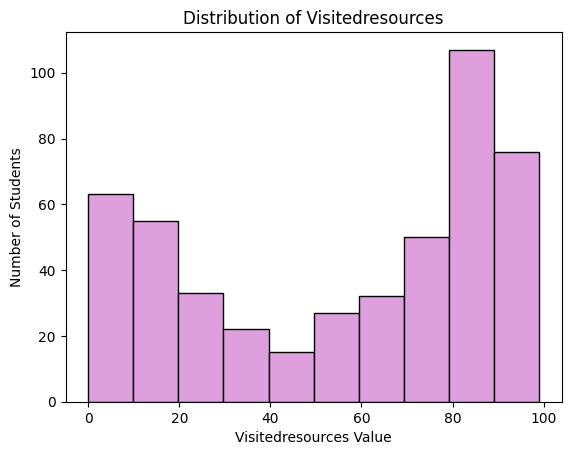

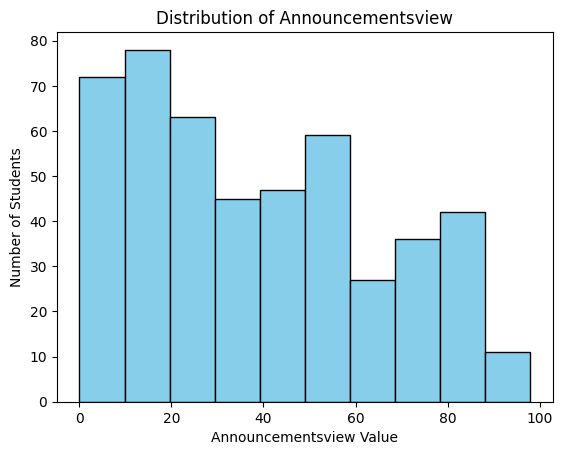

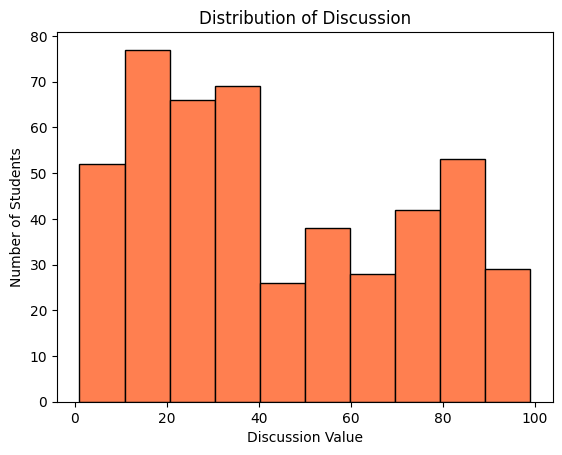

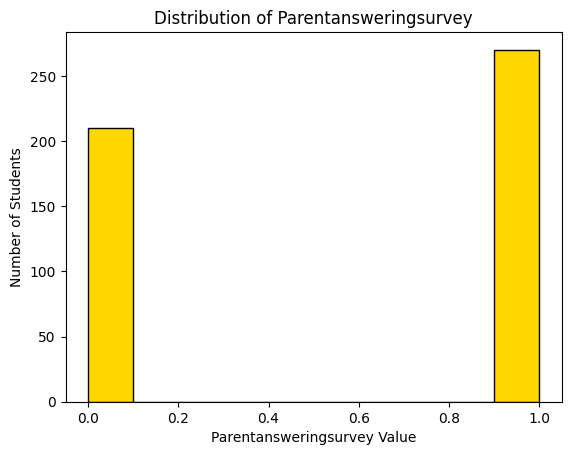

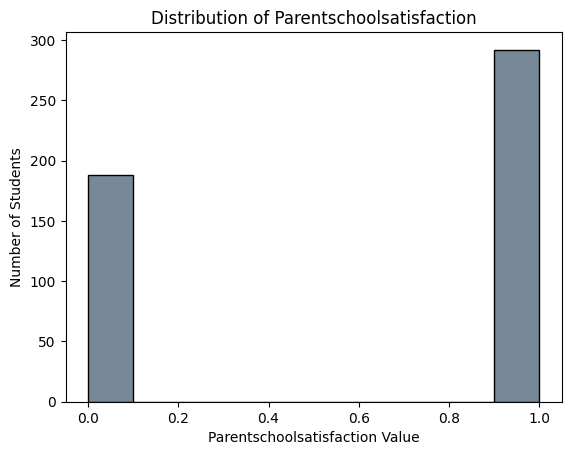

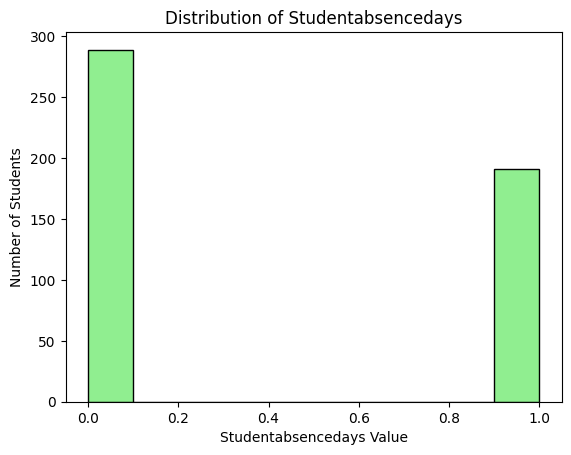

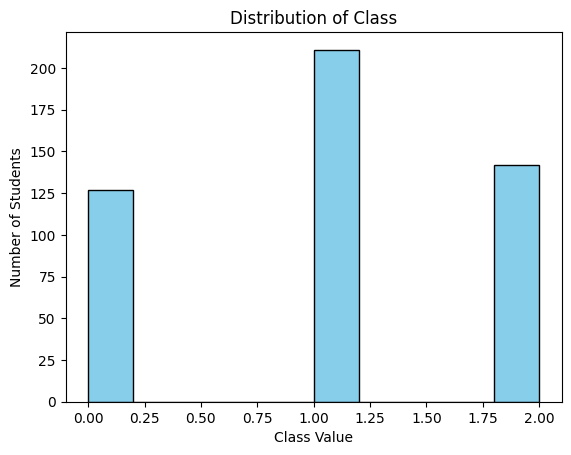

In [8]:
plot_column_distribution(df, 'raisedhands')
plot_column_distribution(df, 'VisITedResources')
plot_column_distribution(df, 'AnnouncementsView')
plot_column_distribution(df, 'Discussion')
plot_column_distribution(df, 'ParentAnsweringSurvey')
plot_column_distribution(df, 'ParentschoolSatisfaction')
plot_column_distribution(df, 'StudentAbsenceDays')
plot_column_distribution(df, 'Class')

I plotted the numbers within each participation category that I will be using in later clustering and machine learning models. I do not believe that these graphs answer my research questions, but it helps to see the distribution of students participation. It is interesting to see how the students as a whole participated more in some activities (i.e. visiting resources) than others (i.e. discussions).

I also wanted to make sure that the classes that we will be predicting are not unbalanced. Though it seems as though the number of middle-performing students is quite a bit higher than those that are of low or high classes. However, this is quite realistic because, due to my general domain knowledge, there are more middle performing students in a class; there are less of both high and low performing students. Thus, we do not need to perform data augmentation in this case and can just train our model on the dataset. If there is less accuracy in the model, we can look into this fact again.

# Cluster the data
We are clustering data to see if we can find natural patterns in our dataset. Though this may not directly answer my research question, I want to see if there is something there to explore in the dataset.

**Attempting to use DBSCAN**

In [9]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [10]:
features = ["raisedhands", "VisITedResources", "AnnouncementsView", "Discussion", "ParentAnsweringSurvey", "ParentschoolSatisfaction", "StudentAbsenceDays"]

# Scale data and then cluster using DBSCAN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# I changed the eps value and min_samples from trial-and-error
# This is discussed in my analysis below
dbscan = DBSCAN(eps=0.9, min_samples=3)
df["cluster_db"] = dbscan.fit_predict(X_scaled)

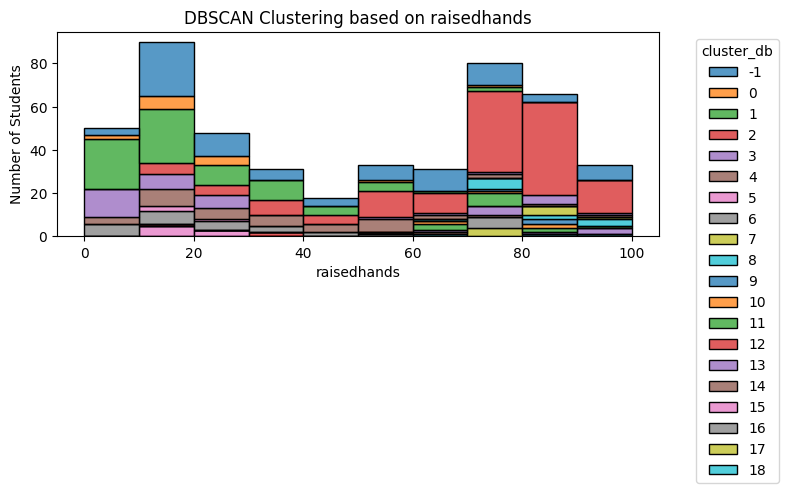

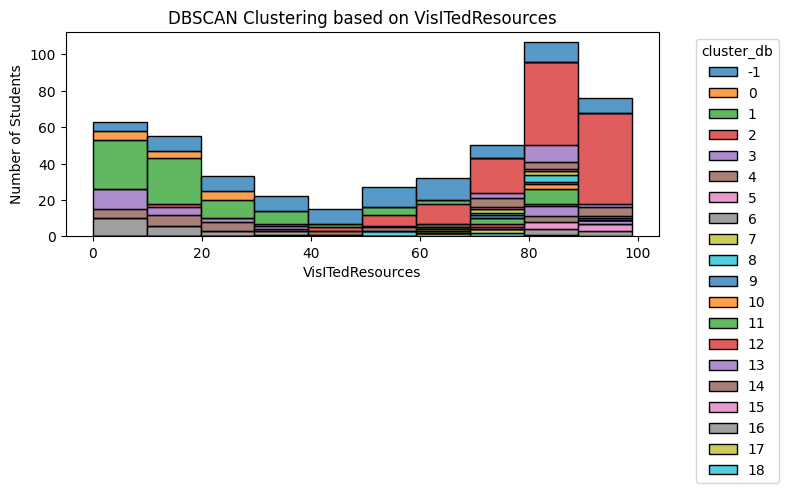

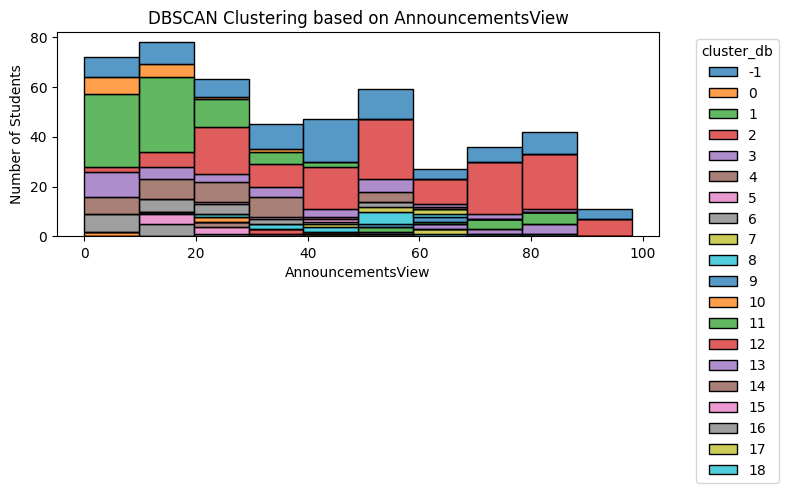

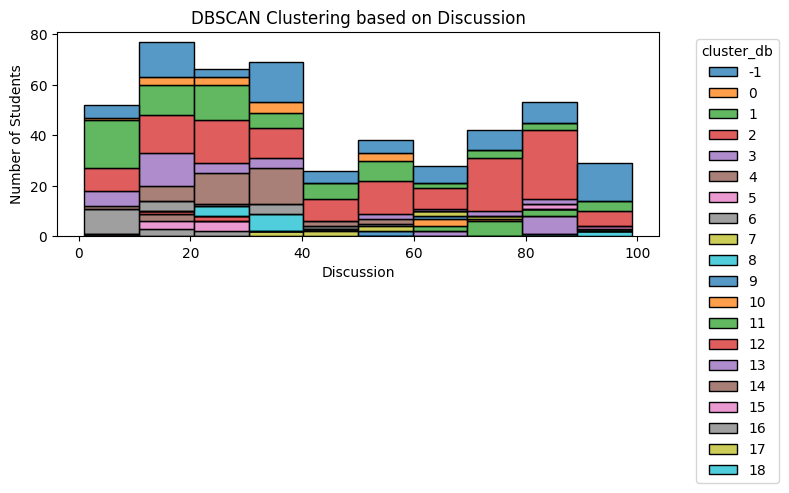

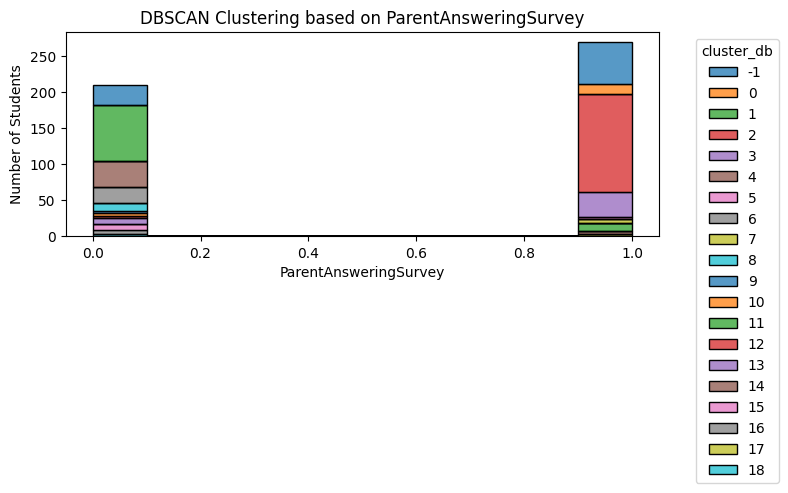

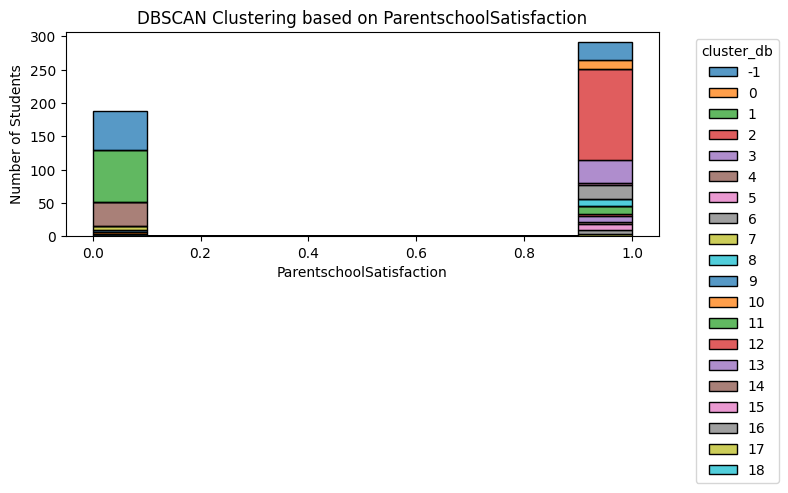

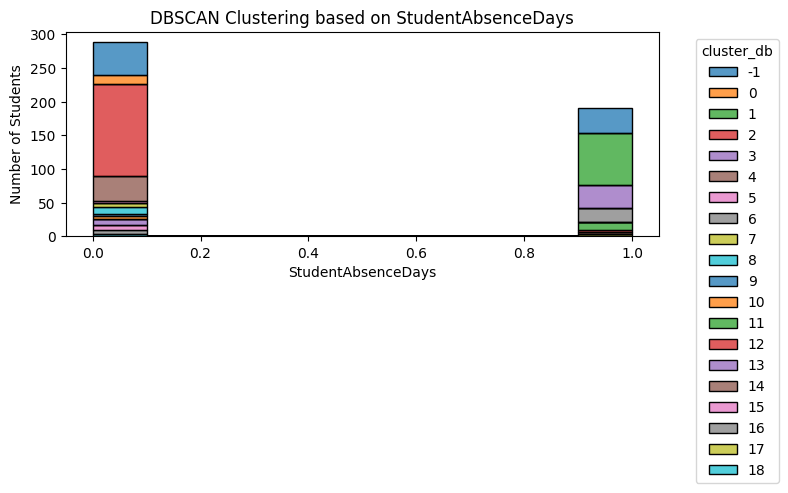

In [11]:
for feature in features:
    plt.figure(figsize=(8, 4))
    ax = sns.histplot(data=df, x=feature, hue="cluster_db", palette="tab10", multiple="stack")
    plt.title(f"DBSCAN Clustering based on {feature}")
    plt.xlabel(feature)
    plt.ylabel("Number of Students")

    legend = ax.get_legend()
    legend.set_bbox_to_anchor((1.05, 1))
    plt.tight_layout()
    plt.show()

DCSCAN has too many clusters for it to be easy to interpret. With 18 different categories, it gets confusing on what data has been clustered togehther. In order to mitigate the great number of outliers, I changed the eps and min_samples values. It seems as though, for this dataset, a lower eps value leads to more outliers and a lower min_samples values leads to more clusters but less outliers.  

This does not seem to be very relevant to our dataset, so We should try k-means instead and see if it is easier to draw conclusions from.

**Attempting to use K-means**

In [12]:
from sklearn.cluster import KMeans
!pip3 install kneed
from kneed import KneeLocator


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
def elbow_method(data, clustering_method, k_min, k_max):
  # Sum of squared distances
  inertia = []

  k_values = list(range(k_min, k_max + 1))

  # K-Means clustering
  for k in k_values:
    kmeans = clustering_method(n_clusters=k, random_state=42)
    kmeans.fit(data)
    inertia.append(kmeans.inertia_)

  kneedle = KneeLocator(k_values, inertia, curve="convex", direction="decreasing")

  # Elbow curve
  plt.figure(figsize=(8, 5))
  plt.plot(k_values, inertia, marker="o", linestyle="--")

  # Line to show where the optimal k is
  optimal_k = kneedle.knee
  plt.axvline(x=optimal_k, color='red', linestyle='--', label="Optimal k")

  plt.legend()
  plt.xlabel("Number of Clusters (K)")
  plt.ylabel("Inertia (Sum of Squared Distances)")
  plt.title("Elbow Method for Optimal K")
  plt.xticks(k_values)

  # Show the plot
  plt.show()
  return optimal_k

c:\Users\ishab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\ishab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\ishab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\ishab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

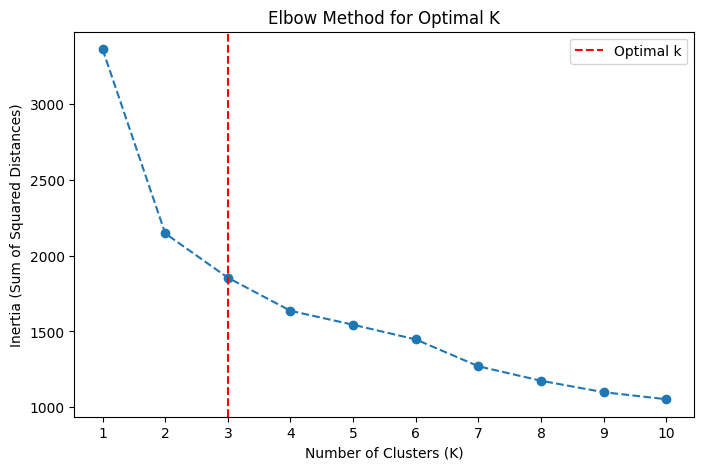

c:\Users\ishab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [14]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator

features =  ["raisedhands", "VisITedResources", "AnnouncementsView", "Discussion", "ParentAnsweringSurvey", "ParentschoolSatisfaction", "StudentAbsenceDays"]
X = df[features]

# Scale, find best k, and run KMeans
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

optimal_k = elbow_method(X_scaled, KMeans, k_min=1, k_max=10)

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df["cluster_kmeans"] = kmeans.fit_predict(X_scaled)

It makes sense that k=3 becuase there are three groups (low, medium, and high) for academic achievement in the dataset. Now, when we perform k-means clustering, it will be easier for us to see how these clusters relate to the different classes.

In [15]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df["cluster_kmeans"] = kmeans.fit_predict(X_scaled)

c:\Users\ishab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


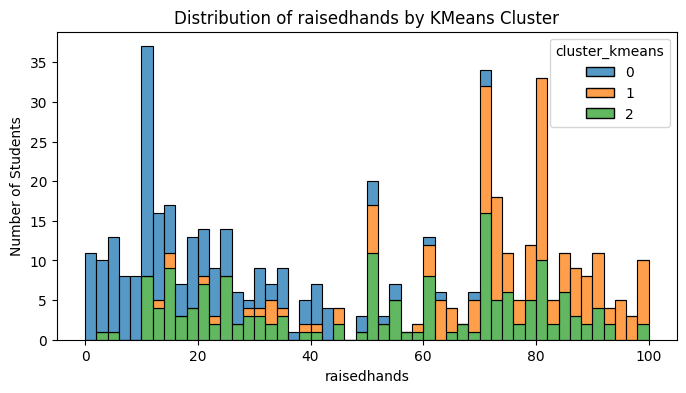

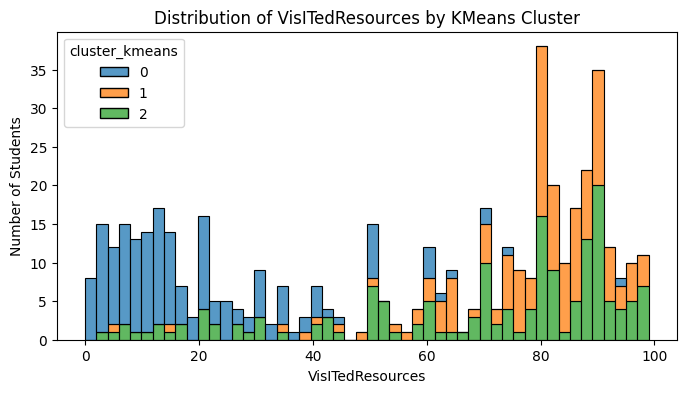

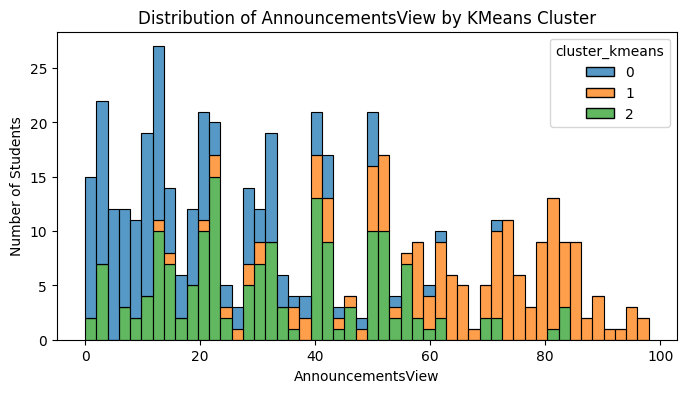

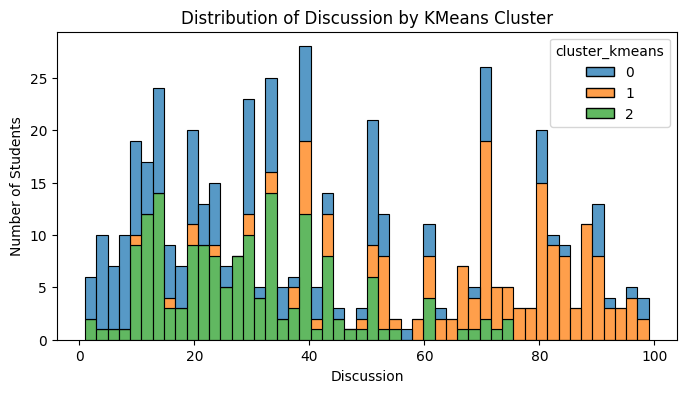

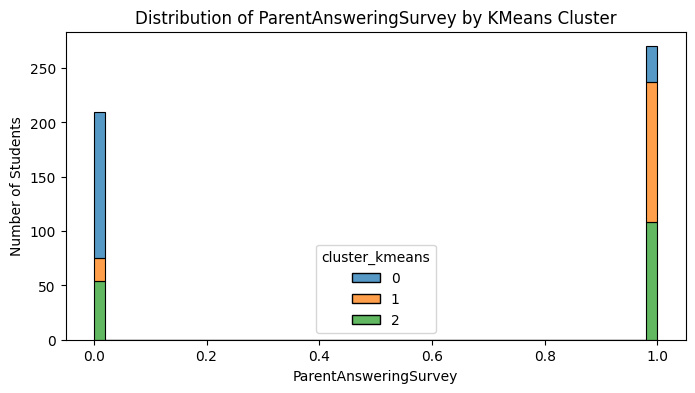

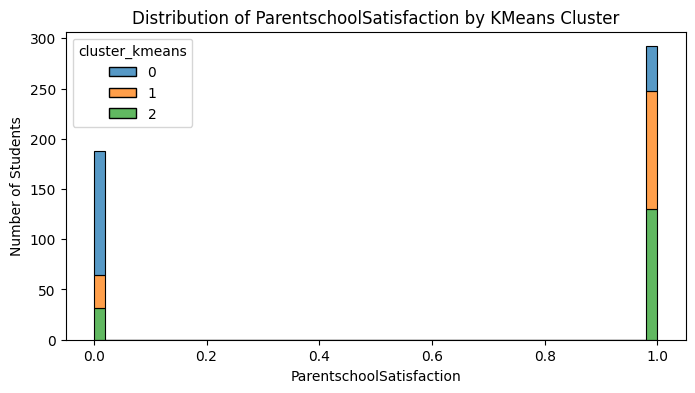

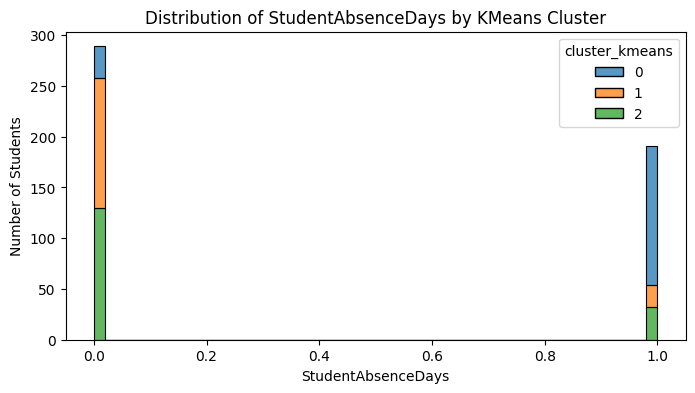

In [16]:
for feature in features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=feature, bins=50, kde=False, hue="cluster_kmeans", palette="tab10", multiple="stack")
    plt.title(f"Distribution of {feature} by KMeans Cluster")
    plt.ylabel("Number of Students")
    plt.xlabel(feature)
    plt.yscale("linear")
    plt.show()

Using k-means clustering, we can see the three categories of students. Cluster 0 (the blue cluster) seems to be more in the lower numbers of each participation. The exceptions include the number of student absence days. Cluster 2, the green cluster, seems to be more clustered around the middle area of our x-axes, going a bit into the higher participation numbers. Lastly, cluster 1, the orange cluster, clusters data at the higher participation ranges for all except student absence days.

When analyzing these graphs, we can see how the clusters represent how much engagement a student has. Blue correspond to lower engagement, orange corresponds to higher engagement, and green correponds to a medium amount of engagements. Though I have not answered my research question yet, I am able to see how it seems like higher levels of engagement are corresponding to higher scores in the class, while lower levels of engagement are correspond to lower scores in the class. The only interesting difference from this pattern is the number of absence days, where it seems like this is flipped.

This is helpful in this project because someone can use values based on these graphs to predict scores. They now have the knowledge of which participation characteristics can help lead to higher participation scores.

# Classfier- predict H, M, L

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report, f1_score, accuracy_score, mean_absolute_percentage_error, ConfusionMatrixDisplay, confusion_matrix

In [18]:
features = ['raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion', 'ParentAnsweringSurvey', 'ParentschoolSatisfaction', 'StudentAbsenceDays']
x = df[features]
y_classification = df['Class']
y_regression = df['Class']

**Data splitting**

In [19]:
from sklearn.model_selection import train_test_split

test_size = 0.3

# Subsampling is 1 because it's not needed
subsampling_ratio = 1
subsampling_elem = int(len(df) * subsampling_ratio)

# Training the model: 70% train and 30% test as we learned in class
x_train_clas, x_test_clas, y_train_clas, y_test_clas = train_test_split(x[:subsampling_elem], y_classification[:subsampling_elem], test_size=0.3, random_state=42)
x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x[:subsampling_elem], y_regression[:subsampling_elem], test_size=0.3, random_state=42)

**Classification**

In [20]:
# Initialize the models we learned about in class
models_clas = {
    'Decision Tree Classifier': DecisionTreeClassifier(random_state = 42),
    'Random Forest Classifier': RandomForestClassifier(n_jobs = -1, random_state = 42),
    'Support Vector Classifier': SVC(),
    'K-Neighbors Classifier': KNeighborsClassifier(n_jobs = -1)
}

# Train, predict, and evaluate each model
results = []

for name, model in models_clas.items():
  model.fit(x_train_clas, y_train_clas)

  y_pred_clas = model.predict(x_test_clas)

  # We will be plotting f1 and accuracy, as we learned in class to do
  f1 = f1_score(y_test_clas, y_pred_clas, average = "macro")
  accuracy = accuracy_score(y_test_clas, y_pred_clas)
  cr = classification_report(y_test_clas, y_pred_clas)

  print(f"Classification Report of {name}:\n{cr}")

  results.append({
      'Model': name,
      'F1': f1,
      'Accuracy': accuracy
  })

# Print out our results
results_df_clas = pd.DataFrame.from_records(results)
print(results_df_clas)

Classification Report of Decision Tree Classifier:
              precision    recall  f1-score   support

           0       0.72      0.76      0.74        45
           1       0.63      0.63      0.63        68
           2       0.52      0.48      0.50        31

    accuracy                           0.64       144
   macro avg       0.62      0.62      0.62       144
weighted avg       0.64      0.64      0.64       144

Classification Report of Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87        45
           1       0.80      0.69      0.74        68
           2       0.64      0.74      0.69        31

    accuracy                           0.77       144
   macro avg       0.76      0.78      0.77       144
weighted avg       0.78      0.77      0.77       144

Classification Report of Support Vector Classifier:
              precision    recall  f1-score   support

           0       0.76      

# Visualize Results




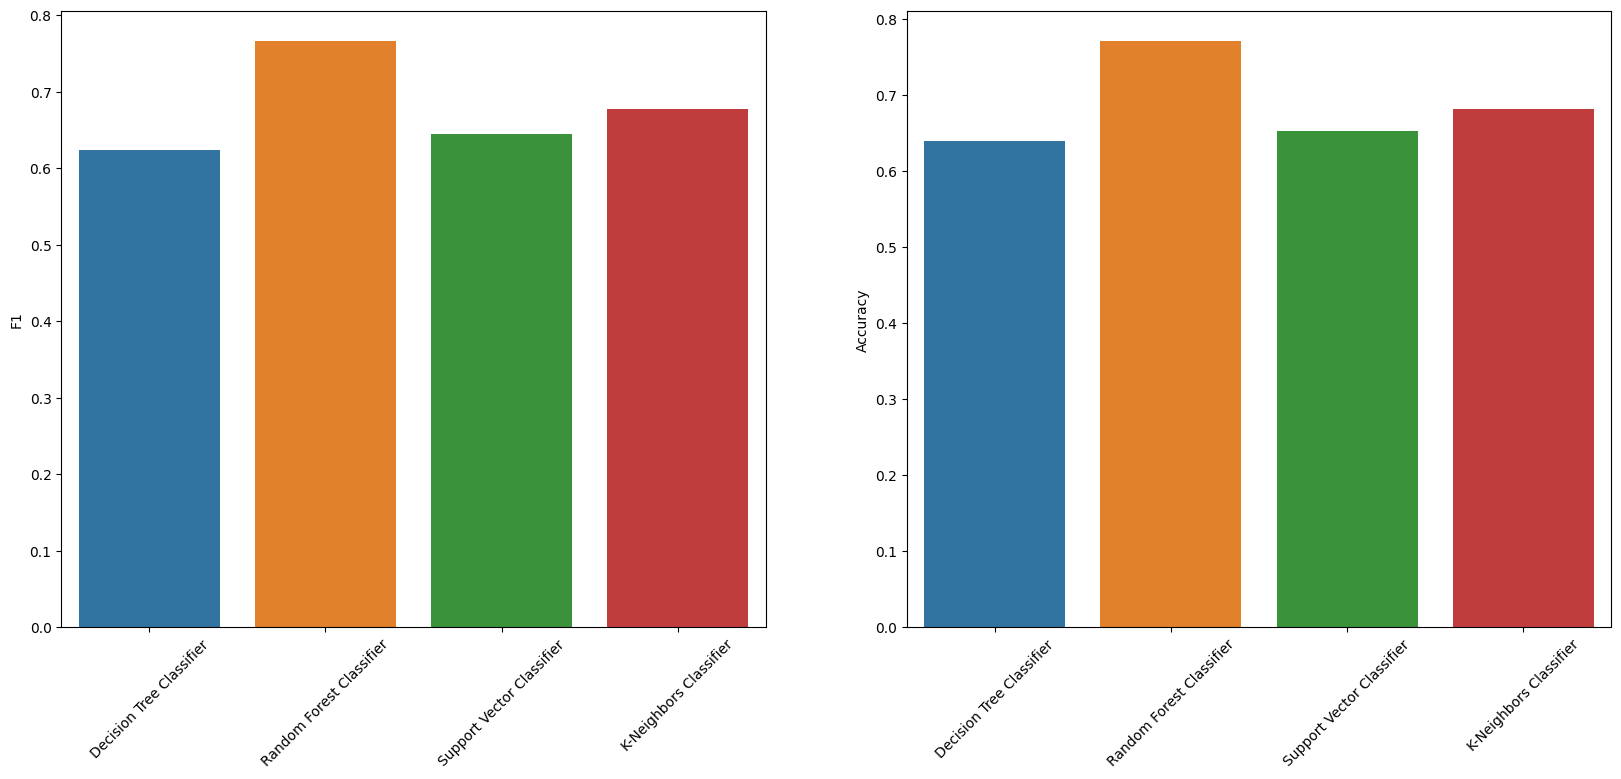

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes = axes.flatten()
metrics = ["F1", "Accuracy"]

# Color of the model's bar is the same between the two models
unique_models = results_df_clas["Model"].unique()
palette = sns.color_palette("tab10", n_colors=len(unique_models))
color_dict = dict(zip(unique_models, palette))

for i in range(len(metrics)):
  ax = axes[i]
  metric = metrics[i]
  sns.barplot(data = results_df_clas, x = "Model", hue="Model", y = metric, ax = ax, palette=color_dict)
  ax.set_xlabel("")
  ax.set_ylabel(metric)
  ax.tick_params(axis='x', rotation=45)

plt.show()

After visualizing the results, it is quite apparent that the Random Forest Classifier is the model that we should be using to predict a student's class (high, medium, or low).The Random Forest Classifier has the highest F1 score, meaning that it is good in recall and precision, and the highest accuracy score. We want the best perfirming model we can find, so this is the one we will use.

# Error Analysis

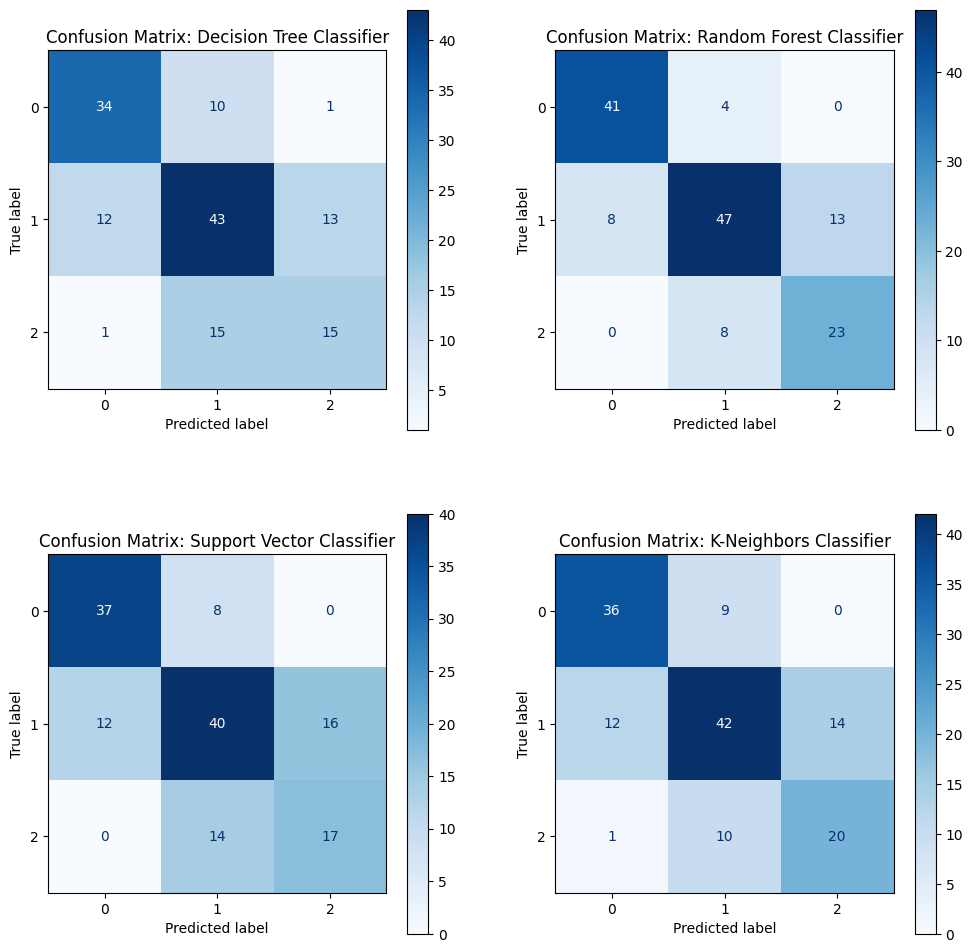

<Figure size 640x480 with 0 Axes>

In [23]:
num_columns = 2
num_rows = 2

fig, axes = plt.subplots(num_rows, num_columns, figsize=(6 * num_columns, 6 * num_rows))
axes = axes.flatten()
m_idx = 0

for name, model in models_clas.items():
    ax = axes[m_idx]
    # Make predictions
    y_pred_model = model.predict(x_test_clas)
    # Calculate confusion matrix
    cm = confusion_matrix(y_test_clas, y_pred_model)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', ax=ax)
    ax.set_title(f"Confusion Matrix: {name}")
    m_idx += 1

plt.show()
plt.clf()

To continue on to test which classifier I should use to answer my research questions, I looked at the confusion matrix for these models with this structure: top left to bottom right diagonals showing correct classifications.

First looking at the correct classifications, the Random Forest beats the other three models in how well they were able to classify the training model for all three classes. When looking at the misclassifications, it misclassified 4 Low classes, 21 Medium classes, and 8 High classes. The combined misclassifications are lower than any other model we tested.

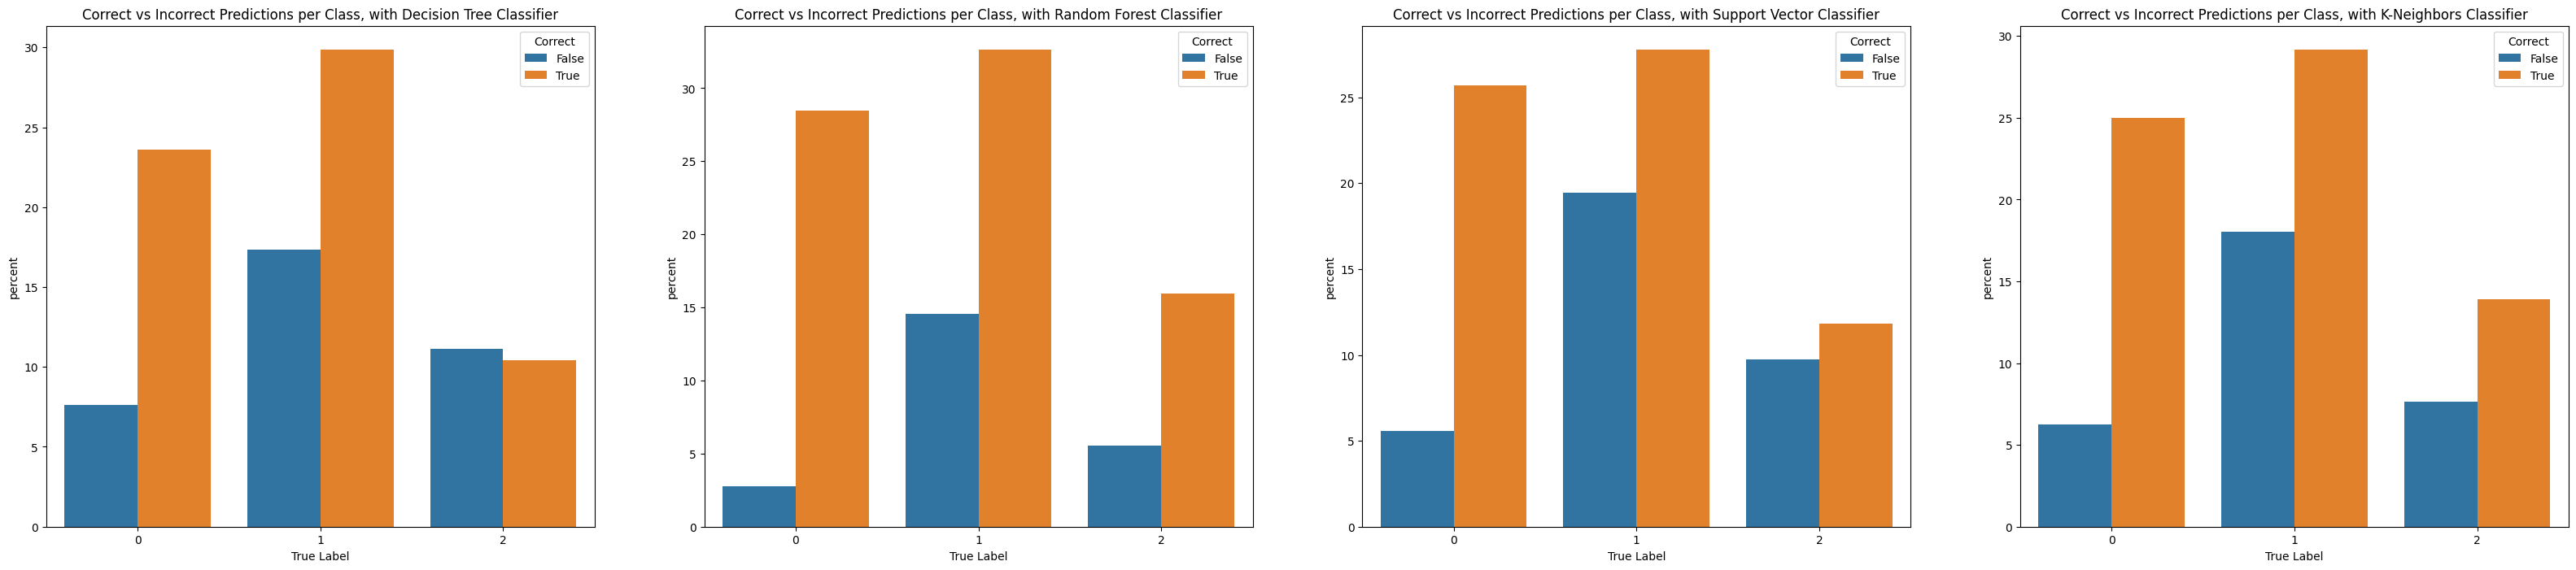

<Figure size 640x480 with 0 Axes>

In [ ]:
# Percent correct on the models above
# Also what we learned in class
fig, axes = plt.subplots(1, len(models_clas), figsize=(40, 8))
axes = axes.flatten()
m_idx = 0
for name, model in models_clas.items():
  ax = axes[m_idx]
  # Make predictions
  y_pred_model = model.predict(x_test_clas)
  errors = pd.DataFrame({
    "True Label": y_test_clas,
    "Predicted Label": y_pred_model
  })
  errors["Correct"] = errors["True Label"] == errors["Predicted Label"]
  # Calculate confusion matrix
  sns.countplot(data=errors, x="True Label", hue="Correct", ax = ax, stat="percent")
  ax.set_title(f"Correct vs Incorrect Predictions per Class, with {name}")
  m_idx+=1

plt.show()
plt.clf()

On these graphs above, we can see another way to visualize which ML model would be best to use. We want to make sure our model has the highest percent of true predictions (leading to the lowest percents of false predictions). We can see that for the three classes, the Random Forest classifier seems to have the highest correct rate. This just solidifies what we learned from the confusion matrix above. 

# Figuring out which of these characteristic most impacts class

In [26]:
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train_clas, y_train_clas)

# Get feature importances
importances = rf.feature_importances_

# Match feature names
feature_importance = pd.Series(importances, index=x.columns)

# Sort and display
feature_importance = feature_importance.sort_values(ascending=False)
print(feature_importance)

VisITedResources            0.243888
raisedhands                 0.214433
AnnouncementsView           0.174729
Discussion                  0.149228
StudentAbsenceDays          0.135284
ParentAnsweringSurvey       0.050192
ParentschoolSatisfaction    0.032247
dtype: float64


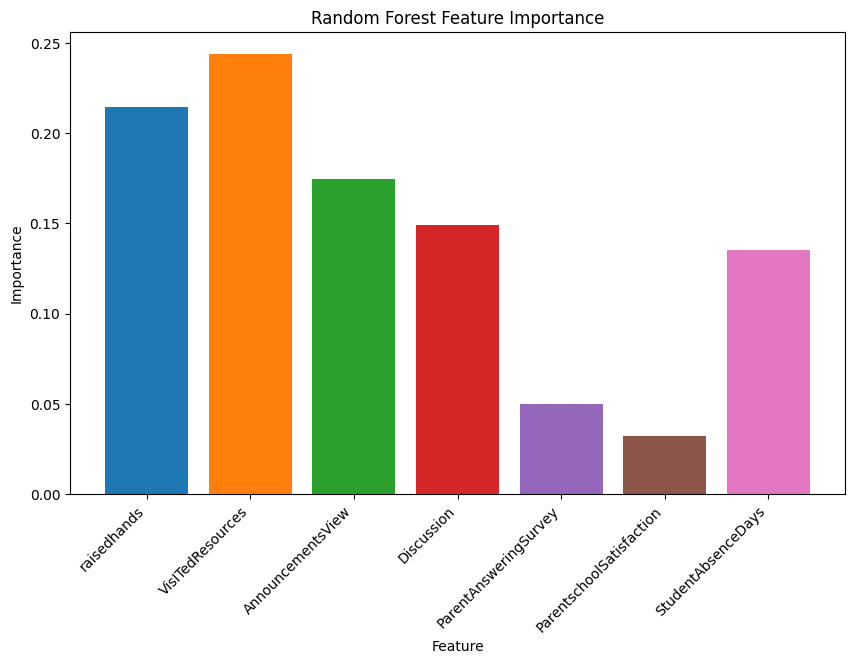

In [27]:
bar_colors = sns.color_palette("tab10", len(x.columns))
plt.figure(figsize=(10, 6))
plt.bar(range(x.shape[1]), importances, color=bar_colors)
plt.xticks(range(x.shape[1]), x.columns, rotation=45, ha='right')
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()

This bar chart shows which features the Random Forest Classifier found most important in predicting student performance. The model gave the highest importance to visiting resources, followed closely by raising hands. Other key predictors included viewing announcements and participating in discussions.

Student absence days, while still important, had less predictive weight than direct engagement metrics. Parental-related features had the lowest influence, showing that the behavior of the students mattered more in their outcome than their parent's opinions and satisfactions.

Before starting this project, I had assumed that a student answering surveys and being satisfied with the school would have a stronger impact on a student's academic performance becuase it would indicate parents being more invested in a students' academic success. However, this may not be true according the graph above.

I had also originally thought that the number of a student's absence days would have a greater impact. In the database, the column of student absence days includes either less than seven days absent or more than seven days absent. Seven days can be quite a few days that a student has missed. If the database had broken down days missed as lesser intervials (i.e. 1-3 days, 3-5 days, etc.), there may have been a greater feature importance.



# Cumulative Feature Importance

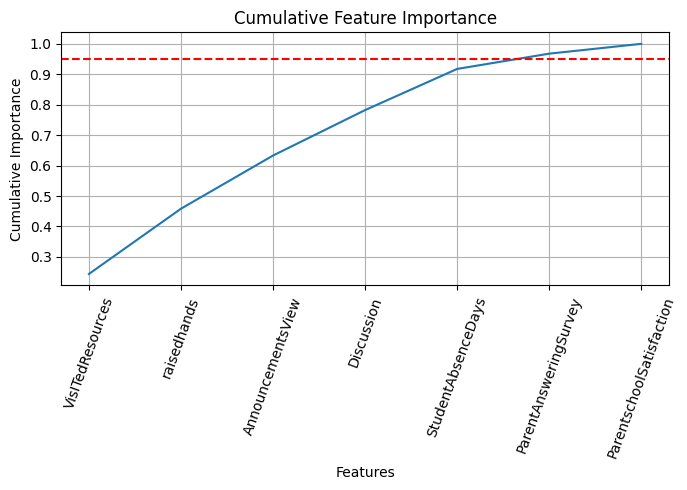

In [36]:
plt.figure(figsize=(7, 5))
cumulative_importance = feature_importance.cumsum()
cumulative_importance.plot()
plt.axhline(y=0.95, color='r', linestyle='--')
plt.title("Cumulative Feature Importance")
plt.xlabel("Features")
plt.ylabel("Cumulative Importance")
plt.xticks(rotation=70)
plt.grid(True)
plt.tight_layout()
plt.show()

This cumulative feature importance graph shows that we can get to the 95% cumulative importance threshold without the parents answering the survey and their satisfaction with the school characteristics. Thus, these potentially could be dropped if we chose to. This model also confirms what the more important features to our model are (starting from the characteristic on the leftmost side of the x-axis and going to the right. )